In [1]:
import sys
print(sys.executable)

C:\Users\DS\miniconda3\python.exe


In [1]:
import optuna

C:\Users\DS\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_sel shape: (39, 10)
y 분포:
label
0    26
1    13
Name: count, dtype: int64
완료!
XGB 최고 CV 점수       : 0.768
XGB 최적 hyperparameter: {'n_estimators': 87, 'max_depth': 6, 'learning_rate': 0.12929577907259418}


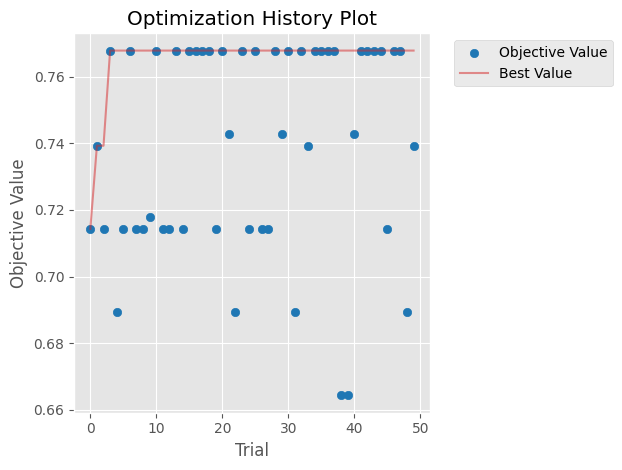

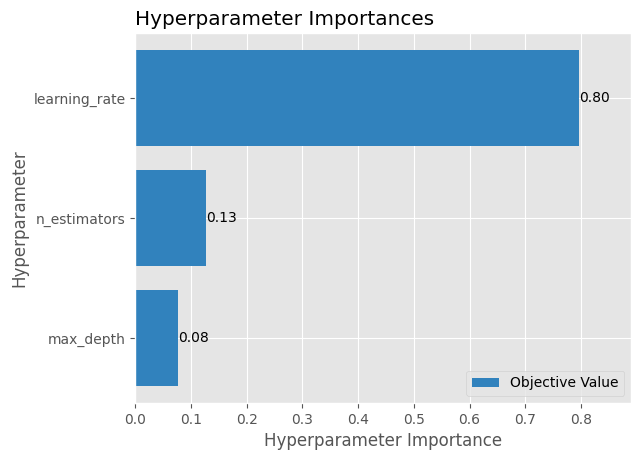

XGB train 정확도: 0.974
XGB CV5 점수    : 0.768
RF 최고 CV 점수       : 0.85
RF 최적 hyperparameter: {'n_estimators': 138, 'max_depth': 8, 'min_samples_split': 3}


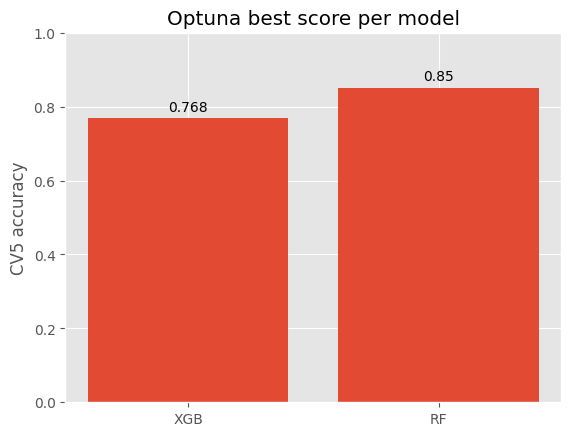

최고 MCC          : 0.431
MCC 기준 best 파라미터: {'n_estimators': 91, 'max_depth': 3, 'learning_rate': 0.20724625728412172}
Pareto 최적 trial: 21개

  sens    spec  파라미터
 0.500   0.893  {'n_estimators': 254, 'max_depth': 5, 'learning_rate': 0.03908889736072421}
 0.267   0.927  {'n_estimators': 85, 'max_depth': 7, 'learning_rate': 0.013583045176032557}
 0.500   0.893  {'n_estimators': 220, 'max_depth': 7, 'learning_rate': 0.15789682609765313}
 0.500   0.893  {'n_estimators': 136, 'max_depth': 6, 'learning_rate': 0.07366493640710399}
 0.500   0.893  {'n_estimators': 230, 'max_depth': 7, 'learning_rate': 0.04280855863920858}
 0.500   0.893  {'n_estimators': 124, 'max_depth': 4, 'learning_rate': 0.26276211720458503}
 0.500   0.893  {'n_estimators': 159, 'max_depth': 4, 'learning_rate': 0.09484552398510891}
 0.500   0.893  {'n_estimators': 284, 'max_depth': 6, 'learning_rate': 0.09965500270655486}
 0.500   0.893  {'n_estimators': 266, 'max_depth': 3, 'learning_rate': 0.04644353958302089}
 0.500   0.8

In [2]:
import pandas as pd
import warnings
import optuna
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


df = pd.read_csv('skin_irritation_2Ddesc.csv')

y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

X = X.dropna(axis=1)
X = X.loc[:, X.std() >= 0.01]

selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)

cols = X.columns[selector.get_support()]
X_sel = X[cols]

print('X_sel shape:', X_sel.shape)
print('y 분포:')
print(y.value_counts())


def objective(trial):
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = XGBClassifier(
        n_estimators=n,
        max_depth=d,
        learning_rate=lr,
        random_state=0
    )

    score = cross_val_score(model, X_sel, y, cv=5).mean()
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print('완료!')
print('XGB 최고 CV 점수       :', round(study.best_value, 3))
print('XGB 최적 hyperparameter:', study.best_params)


from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

plot_optimization_history(study)
plt.show()

plot_param_importances(study)
plt.show()


best_xgb = XGBClassifier(**study.best_params, random_state=0)
best_xgb.fit(X_sel, y)

print('XGB train 정확도:', round(best_xgb.score(X_sel, y), 3))
print('XGB CV5 점수    :', round(cross_val_score(best_xgb, X_sel, y, cv=5).mean(), 3))


def objective_rf(trial):
    n = trial.suggest_int('n_estimators', 50, 500)
    d = trial.suggest_int('max_depth', 2, 20)
    mss = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=d,
        min_samples_split=mss,
        random_state=0
    )

    score = cross_val_score(model, X_sel, y, cv=5).mean()
    return score


study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=30)

print('RF 최고 CV 점수       :', round(study_rf.best_value, 3))
print('RF 최적 hyperparameter:', study_rf.best_params)


scores = [study.best_value, study_rf.best_value]

plt.bar(['XGB', 'RF'], scores)
plt.ylim(0, 1)
plt.ylabel('CV5 accuracy')
plt.title('Optuna best score per model')

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, round(v, 3), ha='center')

plt.show()


def objective_mcc(trial):
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = XGBClassifier(
        n_estimators=n,
        max_depth=d,
        learning_rate=lr,
        random_state=0
    )

    score = cross_val_score(
        model,
        X_sel,
        y,
        cv=5,
        scoring='matthews_corrcoef'
    ).mean()

    return score


study_mcc = optuna.create_study(direction='maximize')
study_mcc.optimize(objective_mcc, n_trials=50)

print('최고 MCC          :', round(study_mcc.best_value, 3))
print('MCC 기준 best 파라미터:', study_mcc.best_params)


spec_scorer = make_scorer(recall_score, pos_label=0)

def objective_multi(trial):
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = XGBClassifier(
        n_estimators=n,
        max_depth=d,
        learning_rate=lr,
        random_state=0
    )

    sens = cross_val_score(model, X_sel, y, cv=5, scoring='recall').mean()
    spec = cross_val_score(model, X_sel, y, cv=5, scoring=spec_scorer).mean()

    return sens, spec


study_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_multi.optimize(objective_multi, n_trials=50)

print(f'Pareto 최적 trial: {len(study_multi.best_trials)}개')
print()
print(f'{"sens":>6}  {"spec":>6}  파라미터')

for t in study_multi.best_trials:
    print(f'{t.values[0]:>6.3f}  {t.values[1]:>6.3f}  {t.params}')


def objective_bal(trial):
    n = trial.suggest_int('n_estimators', 50, 300)
    d = trial.suggest_int('max_depth', 2, 8)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = XGBClassifier(
        n_estimators=n,
        max_depth=d,
        learning_rate=lr,
        random_state=0
    )

    score = cross_val_score(
        model,
        X_sel,
        y,
        cv=5,
        scoring='balanced_accuracy'
    ).mean()

    return score


study_bal = optuna.create_study(direction='maximize')
study_bal.optimize(objective_bal, n_trials=50)

print('Balanced accuracy 최고 점수:', round(study_bal.best_value, 3))
print('Balanced accuracy 기준 best 파라미터:', study_bal.best_params)
print()
print('Accuracy 기준 XGB 최고 점수:', round(study.best_value, 3))
print('Accuracy 기준 XGB best 파라미터:', study.best_params)